<a href="https://colab.research.google.com/github/ArhanTibro/machine-learning-small-projects/blob/main/q_learning_rl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

states=16
actions=4
goal=15

table=np.zeros((states,actions))
print(table)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [2]:
lr=0.8
df=0.95
exploration_p=0.2
epochs=1000



In [3]:
def get_next_state(state,action):
  row,col=divmod(state,4)

  if action==0 and col>0:
    col-=1
  elif action ==1 and col<3:
    col+=1
  elif action==2 and row>0:
    row-=1
  elif action==3 and row<3:
    row+=1

  return row*4+col

In [4]:
for epoch in range(epochs):
  curr=np.random.randint(0,states)

  while True:
    if np.random.rand()<exploration_p:
      action=np.random.randint(0,actions)
    else:
      action=np.argmax(table[curr])
    next=get_next_state(curr,action)
    reward = 1 if next==goal else 0

    table[curr,action] += lr*(reward + df*np.max(table[next])-table[curr,action])

    if next==goal:
      break
    curr=next




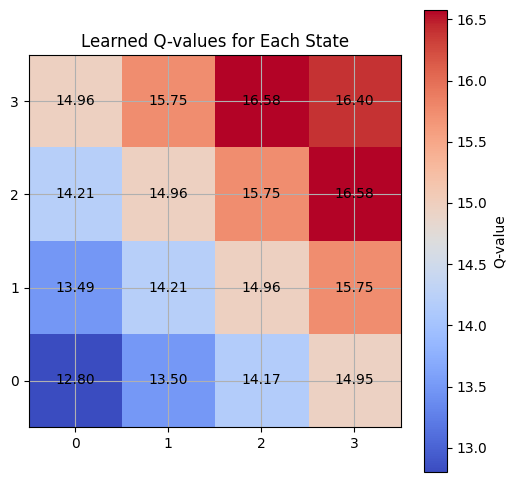

Learned Q-table:
[[10.76627756 12.80198711 11.6908399  11.65431662]
 [11.54773797 13.08363609 12.47898914 13.50129822]
 [11.56353321 11.79640852 11.72827424 14.17247434]
 [13.26625788 10.72744126  9.00313817 14.94558144]
 [12.12935288 13.49249677 10.88236381 13.13660266]
 [12.18606461 14.21221434 12.63848234 14.2038543 ]
 [13.3154951  14.62020506 13.35687952 14.96024998]
 [14.12920323  8.78174773 13.41812862 15.74751268]
 [12.58377367 13.35845915 11.58565578 14.21151976]
 [12.76710297 14.96015404 13.29296778 14.83145679]
 [14.18955947 15.40401428 14.17768423 15.74763156]
 [14.89283416 14.52032202 14.51809764 16.5764539 ]
 [13.91505708 14.96024893 13.42631768 14.00269924]
 [14.06963645 15.74763156 13.86165839 14.41581722]
 [14.95483741 16.57645427 14.93315535 15.74194262]
 [12.03425133 16.21022221 14.58314024 16.39626766]]


In [5]:
import matplotlib.pyplot as plt
q_grid=np.max(table,axis=1).reshape((4,4))

plt.figure(figsize=(6,6))
plt.imshow(q_grid,cmap="coolwarm", interpolation="nearest")
plt.colorbar(label='Q-value')
plt.title('Learned Q-values for Each State')
plt.xticks(np.arange(4), ['0', '1', '2', '3'])
plt.yticks(np.arange(4), ['0', '1', '2', '3'])
plt.gca().invert_yaxis()
plt.grid(True)

for i in range(4):
    for j in range(4):
        plt.text(j, i, f'{q_grid[i, j]:.2f}', ha='center', va='center', color='black')

plt.show()

print("Learned Q-table:")
print(table)